In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv('lung_cancer_dataset_2.csv')
df
#frequencies = df['GENDER'].value_counts()
#print(frequencies)
#print(df.dtypes)


column = ['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING',
       'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN']

    
le = LabelEncoder()
for col in column:
    df[col] = le.fit_transform(df[col])
df = pd.get_dummies(df, drop_first=True)

X = df.drop(columns=['LUNG_CANCER_YES']).values
y = df['LUNG_CANCER_YES'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) 
X_test  = scaler.transform(X_test)       

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

In [2]:
class FNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64,32),
            nn.ReLU(),

            nn.Linear(32,1)
        )

    def forward(self, x):
        return self.network(x)

In [3]:
input_dim = X_train.shape[1]
model = FNN(input_dim)
print(model)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

losses = []
#got rid of auto stop training and manually tested overfitting for better results
##model stopped training too early
for epoch in range(1500):
    model.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/100 — Loss: {avg_loss:.4f}")

FNN(
  (network): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)
Epoch 10/100 — Loss: 0.6181
Epoch 20/100 — Loss: 0.1615
Epoch 30/100 — Loss: 0.1265
Epoch 40/100 — Loss: 0.1132
Epoch 50/100 — Loss: 0.1007
Epoch 60/100 — Loss: 0.0870
Epoch 70/100 — Loss: 0.0907
Epoch 80/100 — Loss: 0.0886
Epoch 90/100 — Loss: 0.0884
Epoch 100/100 — Loss: 0.0856
Epoch 110/100 — Loss: 0.0918
Epoch 120/100 — Loss: 0.0764
Epoch 130/100 — Loss: 0.0734
Epoch 140/100 — Loss: 0.0750
Epoch 150/100 — Loss: 0.0786
Epoch 160/100 — Loss: 0.0685
Epoch 170/100 — Loss: 0.0730
Epoch 180/100 — Loss: 0.0662
Epoch 190/100 — Loss: 0.0704
Epoch 200/100 — Loss: 0.0639
Epoch 210/100 — Loss: 0.06

In [4]:
#show MAE/RMSE
with torch.no_grad():
    preds = model(X_test_t)
    mae  = (preds - y_test_t).abs().mean().item()
    rmse = ((preds - y_test_t) ** 2).mean().sqrt().item()

print(f"MAE:  {mae:.2f} points")
print(f"RMSE: {rmse:.2f} points")

def predict(raw_input_df):
    X_new = scaler.transform(raw_input_df.values)
    X_new[:, study_idx] *= DAMPEN   
    X_t = torch.tensor(X_new, dtype=torch.float32)
    with torch.no_grad():
        return model(X_t).numpy()
#check for overfitting
model.eval()
with torch.no_grad():
   
    tr_preds  = model(X_train_t).numpy().flatten()
    tr_mae    = np.abs(tr_preds - y_train).mean()

    te_preds  = model(X_test_t).numpy().flatten()
    te_mae    = np.abs(te_preds - y_test).mean()

print(f"Train MAE : {tr_mae:.2f}")
print(f"Test  MAE : {te_mae:.2f}")
print(f"Gap       : {te_mae - tr_mae:.2f}")

MAE:  0.09 points
RMSE: 0.19 points
Train MAE : 0.06
Test  MAE : 0.09
Gap       : 0.03


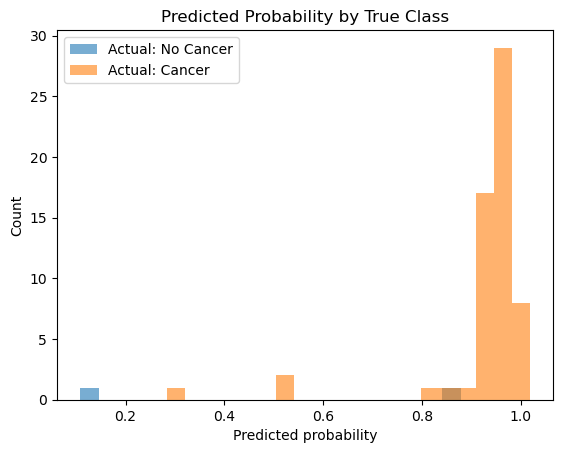

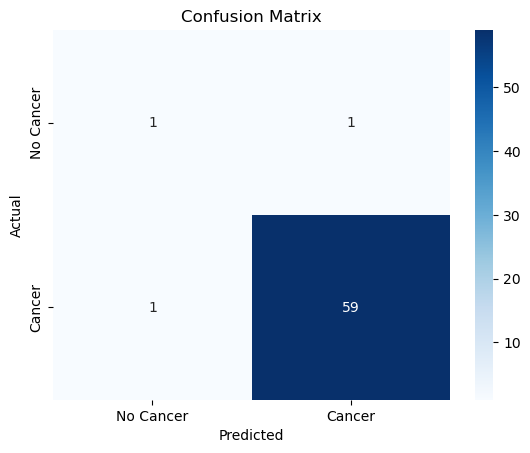

              precision    recall  f1-score   support

   No Cancer       0.50      0.50      0.50         2
      Cancer       0.98      0.98      0.98        60

    accuracy                           0.97        62
   macro avg       0.74      0.74      0.74        62
weighted avg       0.97      0.97      0.97        62

LUNG_CANCER_YES
True     270
False     39
Name: count, dtype: int64


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
y_pred_proba = model(X_test_t).detach().numpy().flatten()
y_true = y_test_t.numpy().flatten()
y_pred_class = (y_pred_proba > 0.5).astype(int)

plt.figure()
plt.hist(y_pred_proba[y_true == 0], bins=20, alpha=0.6, label='Actual: No Cancer')
plt.hist(y_pred_proba[y_true == 1], bins=20, alpha=0.6, label='Actual: Cancer')
plt.xlabel('Predicted probability')
plt.ylabel('Count')
plt.title('Predicted Probability by True Class')
plt.legend()
plt.show()


cm = confusion_matrix(y_true, y_pred_class)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Cancer', 'Cancer'],
            yticklabels=['No Cancer', 'Cancer'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


print(classification_report(y_true, y_pred_class, target_names=['No Cancer', 'Cancer']))
print(df['LUNG_CANCER_YES'].value_counts())

#learned I have too few non-lung cancer patients for the prediction model to be truly accurate

In [6]:
import pandas as pd
import numpy as np

#synthetic data!!!

df = pd.read_csv('lung_cancer_dataset_2.csv')

N = len(df)*2
half = N//2
rng = np.random.default_rng(seed=42)

yes_df = df[df['LUNG_CANCER'] == 'YES']
no_df  = df[df['LUNG_CANCER'] == 'NO']

binary_cols = [c for c in df.columns if c not in ['GENDER', 'AGE', 'LUNG CANCER']]

def bayesian_rate(source_df, col, pseudocount=5):
    yes_count = (source_df[col] == 2).sum()
    no_count = (source_df[col] == 1).sum()
    return (yes_count + pseudocount) / (len(source_df) + 2 * pseudocount)

def sample_group(source_df, n, rng):
    """Generate n synthetic rows using the observed rates in source_df."""

    # AGE
    age = rng.normal(source_df['AGE'].mean(), source_df['AGE'].std(), n).round().astype(int)
    age = np.clip(age, df['AGE'].min(), df['AGE'].max())

    # GENDER
    gender_probs = source_df['GENDER'].value_counts(normalize=True)
    gender = rng.choice(gender_probs.index, size=n, p=gender_probs.values)

    # Binary symptom columns
    binary = {}
    for col in binary_cols:
        p2 = bayesian_rate(source_df, col, pseudocount=5)
        binary[col] = rng.choice([1, 2], size=n, p=[1 - p2, p2])

    return pd.DataFrame({'GENDER': gender, 'AGE': age, **binary})

yes_synthetic = sample_group(yes_df, half, rng)
yes_synthetic['LUNG_CANCER'] = 'YES'

no_synthetic = sample_group(no_df, half, rng)
no_synthetic['LUNG_CANCER'] = 'NO'

synthetic_df = pd.concat([yes_synthetic, no_synthetic]).sample(frac=1, random_state=42).reset_index(drop=True)
synthetic_df.to_csv('survey_lung_cancer_synthetic_balanced.csv', index=False)

print(synthetic_df.columns)
print(synthetic_df.columns.tolist())
df.columns = df.columns.str.strip()

Index(['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING',
       'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER'],
      dtype='object')
['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER']


In [7]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

df_2 = synthetic_df


column = ['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING',
       'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN']

le = LabelEncoder()
for col in column:
    df_2[col] = le.fit_transform(df_2[col])
df_2 = pd.get_dummies(df_2, drop_first=True)

x = df_2.drop(columns=['LUNG_CANCER_YES']).values
Y = df_2['LUNG_CANCER_YES'].values

x_train, x_test, Y_train, Y_test = train_test_split(x, Y, test_size=0.2, random_state=42)

synthetic_scaler = StandardScaler()
x_train = scaler.fit_transform(x_train) 
x_test  = scaler.transform(x_test)       

x_train_t = torch.tensor(x_train, dtype=torch.float32)
x_test_t  = torch.tensor(x_test,  dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32).unsqueeze(1)
Y_test_t  = torch.tensor(Y_test,  dtype=torch.float32).unsqueeze(1)

synthetic_train_loader = DataLoader(
    TensorDataset(x_train_t, Y_train_t), batch_size=32, shuffle=True)

In [8]:
class SyntheticFNN(nn.Module):
    def __init__(self, synthetic_input_dim):
        super().__init__()
        self.synthetic_network = nn.Sequential(
            nn.Linear(synthetic_input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )
    def forward(self, x):
        return self.synthetic_network(x)

synthetic_input_dim = x_train.shape[1]
synthetic_model = SyntheticFNN(synthetic_input_dim)

SyntheticFNN(
  (synthetic_network): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)
Epoch 10/1500 — Loss: 0.6481
Epoch 20/1500 — Loss: 0.4723
Epoch 30/1500 — Loss: 0.3601
Epoch 40/1500 — Loss: 0.3272
Epoch 50/1500 — Loss: 0.3268
Epoch 60/1500 — Loss: 0.3289
Epoch 70/1500 — Loss: 0.3153
Epoch 80/1500 — Loss: 0.3162
Epoch 90/1500 — Loss: 0.2991
Epoch 100/1500 — Loss: 0.2859
Epoch 110/1500 — Loss: 0.2719
Epoch 120/1500 — Loss: 0.2725
Epoch 130/1500 — Loss: 0.2513
Epoch 140/1500 — Loss: 0.2655
Epoch 150/1500 — Loss: 0.2752
Epoch 160/1500 — Loss: 0.2444
Epoch 170/1500 — Loss: 0.2462
Epoch 180/1500 — Loss: 0.2479
Epoch 190/1500 — Loss: 0.2540
Epoch 200/1500 — 

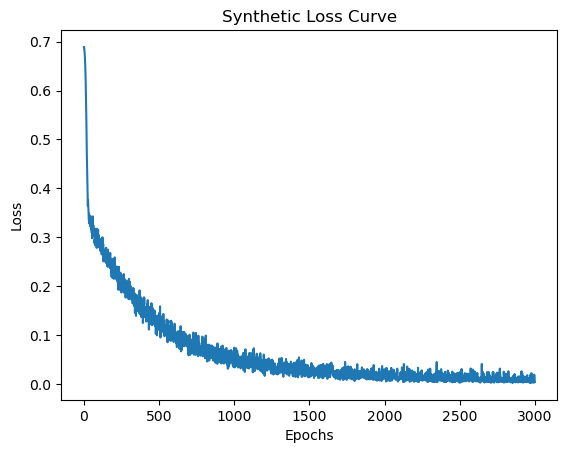

In [9]:
synthetic_input_dim = x_train.shape[1]
synthetic_model = SyntheticFNN(synthetic_input_dim)
print(synthetic_model)

synthetic_criterion = nn.BCEWithLogitsLoss()
synthetic_optimizer = torch.optim.Adam(synthetic_model.parameters(), lr=0.0001)

synthetic_losses = []

for synthetic_epoch in range(3000):
    synthetic_model.train()
    synthetic_epoch_loss = 0
    for x_batch, Y_batch in synthetic_train_loader:
        synthetic_optimizer.zero_grad()
        synthetic_preds = synthetic_model(x_batch)
        synthetic_loss = synthetic_criterion(synthetic_preds, Y_batch)
        synthetic_loss.backward()
        synthetic_optimizer.step()
        synthetic_epoch_loss += synthetic_loss.item()

    synthetic_avg_loss = synthetic_epoch_loss / len(synthetic_train_loader)
    synthetic_losses.append(synthetic_avg_loss)
    if (synthetic_epoch + 1) % 10 == 0:
        print(f"Epoch {synthetic_epoch+1}/1500 — Loss: {synthetic_avg_loss:.4f}")

plt.plot(synthetic_losses)
plt.title('Synthetic Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

MAE:  0.1928
RMSE: 0.4186
Accuracy: 0.8065
LUNG_CANCER_YES
True     309
False    309
Name: count, dtype: int64


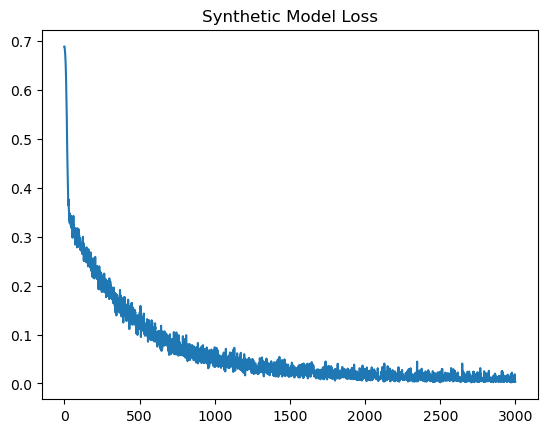

In [10]:
#show MAE/RMSE
def synthetic_predict(synthetic_raw_input_df):
    x_new = synthetic_scaler.transform(synthetic_raw_input_df.values)
    x_new[:, synthetic_study_idx] *= DAMPEN
    x_t = torch.tensor(x_new, dtype=torch.float32)
    with torch.no_grad():
        return synthetic_model(x_t).numpy()

# Check for overfitting
synthetic_model.eval()
with torch.no_grad():
    synthetic_preds = synthetic_model(x_test_t)
    synthetic_preds = torch.sigmoid(synthetic_preds)
    synthetic_mae  = (synthetic_preds - Y_test_t).abs().mean().item()
    synthetic_rmse = ((synthetic_preds - Y_test_t) ** 2).mean().sqrt().item()

print(f"MAE:  {synthetic_mae:.4f}")
print(f"RMSE: {synthetic_rmse:.4f}")

synthetic_pred_labels = (synthetic_preds > 0.5).float()
synthetic_accuracy = (synthetic_pred_labels == Y_test_t).float().mean().item()
print(f"Accuracy: {synthetic_accuracy:.4f}")

print(df_2['LUNG_CANCER_YES'].value_counts())

# Check how many epochs before loss stopped improving
import matplotlib.pyplot as plt
plt.plot(synthetic_losses)
plt.title('Synthetic Model Loss')
plt.show()

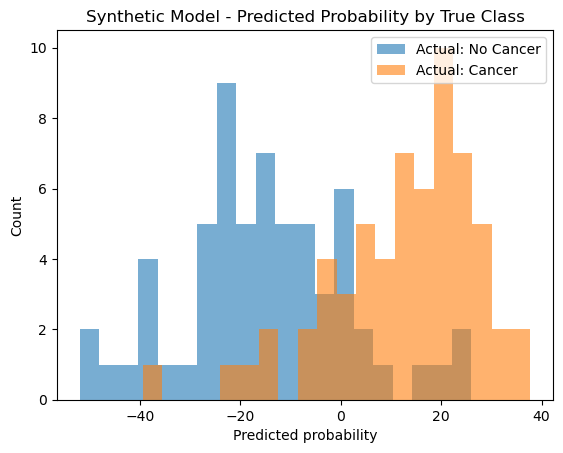

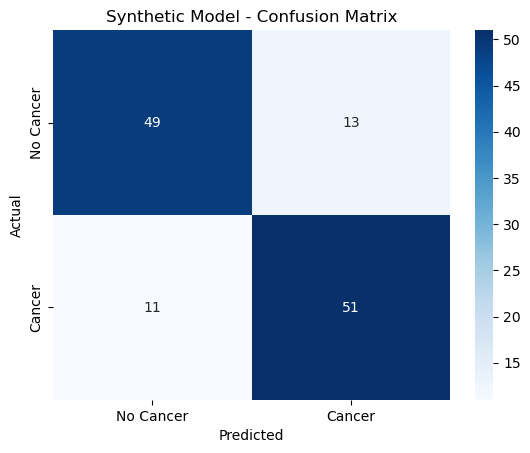

              precision    recall  f1-score   support

   No Cancer       0.82      0.79      0.80        62
      Cancer       0.80      0.82      0.81        62

    accuracy                           0.81       124
   macro avg       0.81      0.81      0.81       124
weighted avg       0.81      0.81      0.81       124

LUNG_CANCER_YES
True     309
False    309
Name: count, dtype: int64
BCEWithLogitsLoss()


In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

synthetic_model.eval()
synthetic_Y_pred_proba = synthetic_model(x_test_t).detach().numpy().flatten()
synthetic_Y_true = Y_test_t.numpy().flatten()
synthetic_Y_pred_class = (synthetic_Y_pred_proba > 0.5).astype(int)

plt.figure()
plt.hist(synthetic_Y_pred_proba[synthetic_Y_true == 0], bins=20, alpha=0.6, label='Actual: No Cancer')
plt.hist(synthetic_Y_pred_proba[synthetic_Y_true == 1], bins=20, alpha=0.6, label='Actual: Cancer')
plt.xlabel('Predicted probability')
plt.ylabel('Count')
plt.title('Synthetic Model - Predicted Probability by True Class')
plt.legend()
plt.show()

synthetic_cm = confusion_matrix(synthetic_Y_true, synthetic_Y_pred_class)
plt.figure()
sns.heatmap(synthetic_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Cancer', 'Cancer'],
            yticklabels=['No Cancer', 'Cancer'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Synthetic Model - Confusion Matrix')
plt.show()

print(classification_report(synthetic_Y_true, synthetic_Y_pred_class, target_names=['No Cancer', 'Cancer']))
print(df_2['LUNG_CANCER_YES'].value_counts())
print(synthetic_criterion)

In [12]:
# Separate real data by class
real_no_cancer_idx = np.where(y_train == 0)[0]
real_cancer_idx = np.where(y_train == 1)[0]

print(f"Total real No Cancer: {len(real_no_cancer_idx)}")
print(f"Total real Cancer: {len(real_cancer_idx)}")

# Take 30 of each for training
train_no_cancer_idx = real_no_cancer_idx[:15]
train_cancer_idx = real_cancer_idx[:15]

# Rest goes to test
test_no_cancer_idx = real_no_cancer_idx[15:]
test_cancer_idx = real_cancer_idx[15:]

print(f"\nReal No Cancer in training: {len(train_no_cancer_idx)}")
print(f"Real Cancer in training: {len(train_cancer_idx)}")
print(f"\nReal No Cancer in test: {len(test_no_cancer_idx)}")
print(f"Real Cancer in test: {len(test_cancer_idx)}")

# Combine synthetic and real for training
x_combined_train = np.concatenate([x_train, 
                                    X_train[train_no_cancer_idx], 
                                    X_train[train_cancer_idx]], axis=0)
y_combined_train = np.concatenate([Y_train, 
                                    y_train[train_no_cancer_idx], 
                                    y_train[train_cancer_idx]], axis=0)

# Shuffle training
shuffle_idx = np.random.permutation(len(y_combined_train))
x_combined_train = x_combined_train[shuffle_idx]
y_combined_train = y_combined_train[shuffle_idx]

# Build real test set from remaining real data
x_real_test = np.concatenate([X_train[test_no_cancer_idx], 
                               X_train[test_cancer_idx]], axis=0)
y_real_test = np.concatenate([y_train[test_no_cancer_idx], 
                               y_train[test_cancer_idx]], axis=0)

# Check how many no cancer in test
print(f"\nSynthetic No Cancer available for test: {(Y_test == 0).sum()}")
print(f"Real No Cancer in test: {len(test_no_cancer_idx)}")

# Balance test data with synthetic no cancer if needed
difference = (y_real_test == 1).sum() - (y_real_test == 0).sum()
synthetic_extra_x = x_test[Y_test == 0][:difference]
synthetic_extra_y = Y_test[Y_test == 0][:difference]

x_mixed_test_combined = np.concatenate([x_real_test, synthetic_extra_x], axis=0)
y_mixed_test_combined = np.concatenate([y_real_test, synthetic_extra_y], axis=0)

# Shuffle test
shuffle_idx = np.random.permutation(len(y_mixed_test_combined))
x_mixed_test_combined = x_mixed_test_combined[shuffle_idx]
y_mixed_test_combined = y_mixed_test_combined[shuffle_idx]

print(f"\nFinal Test Set:")
print(f"No Cancer: {(y_mixed_test_combined == 0).sum()}")
print(f"Cancer: {(y_mixed_test_combined == 1).sum()}")

# Scale and convert to tensors
mixed_scaler = StandardScaler()
x_mixed_train = mixed_scaler.fit_transform(x_combined_train)
x_mixed_test  = mixed_scaler.transform(x_mixed_test_combined)

x_mixed_train_t = torch.tensor(x_mixed_train, dtype=torch.float32)
y_mixed_train_t = torch.tensor(y_combined_train, dtype=torch.float32).unsqueeze(1)
x_mixed_test_t  = torch.tensor(x_mixed_test,  dtype=torch.float32)
y_mixed_test_t  = torch.tensor(y_mixed_test_combined, dtype=torch.float32).unsqueeze(1)

mixed_train_loader = DataLoader(
    TensorDataset(x_mixed_train_t, y_mixed_train_t), batch_size=32, shuffle=True)

Total real No Cancer: 37
Total real Cancer: 210

Real No Cancer in training: 15
Real Cancer in training: 15

Real No Cancer in test: 22
Real Cancer in test: 195

Synthetic No Cancer available for test: 62
Real No Cancer in test: 22

Final Test Set:
No Cancer: 84
Cancer: 195


In [13]:
class MixedFNN(nn.Module):
    def __init__(self, mixed_input_dim):
        super().__init__()
        self.mixed_network = nn.Sequential(
            nn.Linear(mixed_input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.mixed_network(x)

mixed_input_dim = x_mixed_train.shape[1]
mixed_model = MixedFNN(mixed_input_dim)


In [14]:
mixed_input_dim = x_mixed_train.shape[1]
mixed_model = MixedFNN(mixed_input_dim)
print(mixed_model)

mixed_criterion = nn.BCEWithLogitsLoss()
mixed_optimizer = torch.optim.Adam(mixed_model.parameters(), lr=0.0001)

mixed_losses = []

for mixed_epoch in range(3500):
    mixed_model.train()
    mixed_epoch_loss = 0
    for x_batch, Y_batch in mixed_train_loader:
        mixed_optimizer.zero_grad()
        mixed_preds = mixed_model(x_batch)
        mixed_loss = mixed_criterion(mixed_preds, Y_batch)
        mixed_loss.backward()
        mixed_optimizer.step()
        mixed_epoch_loss += mixed_loss.item()


    mixed_avg_loss = mixed_epoch_loss / len(mixed_train_loader)
    mixed_losses.append(mixed_avg_loss)
    if (mixed_epoch + 1) % 10 == 0:
        print(f"Epoch {mixed_epoch+1}/3000 — Loss: {mixed_avg_loss:.4f}")

MixedFNN(
  (mixed_network): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)
Epoch 10/3000 — Loss: 0.6220
Epoch 20/3000 — Loss: 0.4110
Epoch 30/3000 — Loss: 0.3322
Epoch 40/3000 — Loss: 0.3173
Epoch 50/3000 — Loss: 0.3101
Epoch 60/3000 — Loss: 0.2923
Epoch 70/3000 — Loss: 0.2914
Epoch 80/3000 — Loss: 0.2788
Epoch 90/3000 — Loss: 0.2661
Epoch 100/3000 — Loss: 0.2642
Epoch 110/3000 — Loss: 0.2562
Epoch 120/3000 — Loss: 0.2380
Epoch 130/3000 — Loss: 0.2202
Epoch 140/3000 — Loss: 0.2465
Epoch 150/3000 — Loss: 0.2094
Epoch 160/3000 — Loss: 0.2139
Epoch 170/3000 — Loss: 0.2033
Epoch 180/3000 — Loss: 0.1970
Epoch 190/3000 — Loss: 0.1960
Epoch 

MAE:  0.2347
RMSE: 0.4666
Accuracy: 0.7599


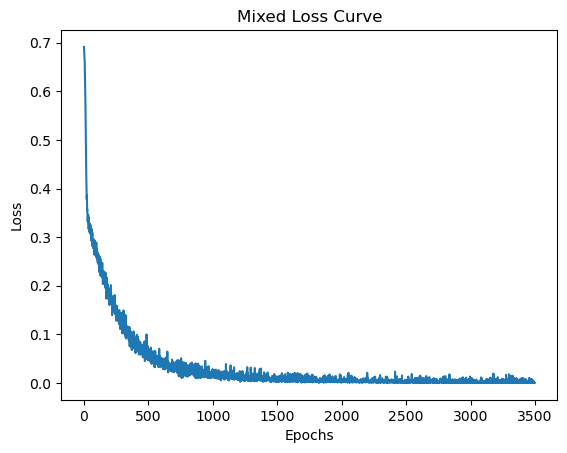

Real No Cancer in training: 15
Real Cancer in training: 15
Real No Cancer in test: 22
Real Cancer in test: 195
Final Test No Cancer: 84
Final Test Cancer: 195


In [15]:
mixed_model.eval()
with torch.no_grad():
    mixed_preds = mixed_model(x_mixed_test_t)
    mixed_mae  = (mixed_preds - y_mixed_test_t).abs().mean().item()
    mixed_rmse = ((mixed_preds - y_mixed_test_t) ** 2).mean().sqrt().item()

print(f"MAE:  {mixed_mae:.4f}")
print(f"RMSE: {mixed_rmse:.4f}")

mixed_pred_labels = (mixed_preds > 0.5).float()
mixed_accuracy = (mixed_pred_labels == y_mixed_test_t).float().mean().item()
print(f"Accuracy: {mixed_accuracy:.4f}")

plt.plot(mixed_losses)
plt.title('Mixed Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

print(f"Real No Cancer in training: {len(train_no_cancer_idx)}")
print(f"Real Cancer in training: {len(train_cancer_idx)}")
print(f"Real No Cancer in test: {len(test_no_cancer_idx)}")
print(f"Real Cancer in test: {len(test_cancer_idx)}")
print(f"Final Test No Cancer: {(y_mixed_test_combined == 0).sum()}")
print(f"Final Test Cancer: {(y_mixed_test_combined == 1).sum()}")

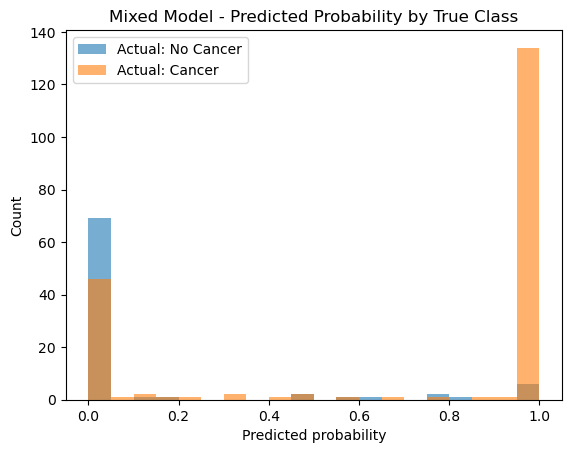

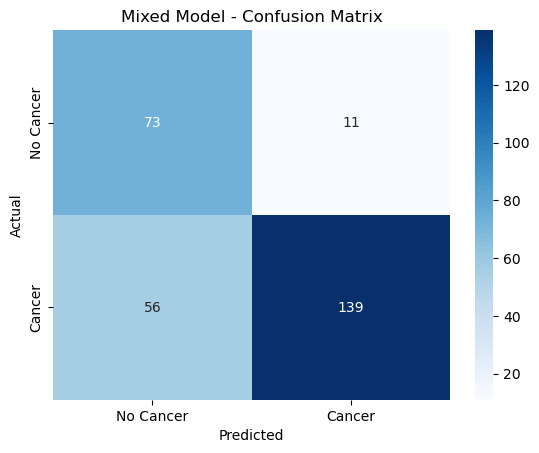

              precision    recall  f1-score   support

   No Cancer       0.57      0.87      0.69        84
      Cancer       0.93      0.71      0.81       195

    accuracy                           0.76       279
   macro avg       0.75      0.79      0.75       279
weighted avg       0.82      0.76      0.77       279



In [16]:
mixed_model.eval()
mixed_Y_pred_proba = mixed_model(x_mixed_test_t).detach().numpy().flatten()
mixed_Y_true = y_mixed_test_t.numpy().flatten()
mixed_Y_pred_class = (mixed_Y_pred_proba > 0.5).astype(int)

plt.figure()
plt.hist(mixed_Y_pred_proba[mixed_Y_true == 0], bins=20, alpha=0.6, label='Actual: No Cancer')
plt.hist(mixed_Y_pred_proba[mixed_Y_true == 1], bins=20, alpha=0.6, label='Actual: Cancer')
plt.xlabel('Predicted probability')
plt.ylabel('Count')
plt.title('Mixed Model - Predicted Probability by True Class')
plt.legend()
plt.show()

mixed_cm = confusion_matrix(mixed_Y_true, mixed_Y_pred_class)
plt.figure()
sns.heatmap(mixed_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Cancer', 'Cancer'],
            yticklabels=['No Cancer', 'Cancer'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Mixed Model - Confusion Matrix')
plt.show()

print(classification_report(mixed_Y_true, mixed_Y_pred_class, target_names=['No Cancer', 'Cancer']))